[![preview notebook](https://img.shields.io/static/v1?label=render%20on&logo=github&color=87ce3e&message=GitHub)](https://github.com/open-atmos/PySDM/blob/main/examples/PySDM_examples/Arabas_and_Pawlowska_2011/fig_2.ipynb)
[![launch on mybinder.org](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/open-atmos/PySDM.git/main?urlpath=lab/tree/examples/PySDM_examples/Arabas_and_Pawlowska_2011/fig_2.ipynb)
[![launch on Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/open-atmos/PySDM/blob/main/examples/PySDM_examples/Arabas_and_Pawlowska_2011/fig_2.ipynb)

#### based on Fig. 2 from Arabas and Pawlowska 2011 "Adaptive method of lines for multi-component aerosol condensational growth and CCN activation"
https://doi.org/10.5194/gmd-4-15-2011

In [1]:
import os, sys
os.environ['NUMBA_THREADING_LAYER'] = 'workqueue'  # PySDM & PyMPDATA don't work with TBB; OpenMP has extra dependencies on macOS
if 'google.colab' in sys.modules:
    !pip --quiet install open-atmos-jupyter-utils
    from open_atmos_jupyter_utils import pip_install_on_colab
    pip_install_on_colab('PySDM-examples', 'PySDM')

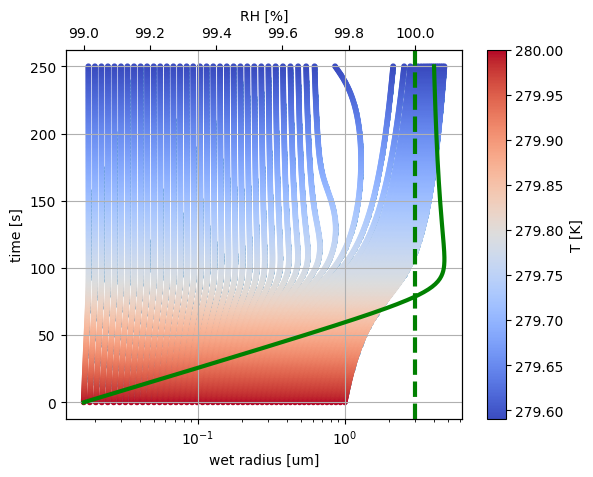

In [1]:
from matplotlib import pyplot
from PySDM.physics import si, in_unit
from PySDM.initialisation import discretise_multiplicities
from PySDM.initialisation.hygroscopic_equilibrium import equilibrate_wet_radii
from PySDM.initialisation.spectra import Lognormal
from PySDM.initialisation.sampling import spectral_sampling
from PySDM.backends import CPU
from PySDM.dynamics import AmbientThermodynamics, Condensation
from PySDM.environments import Parcel
from PySDM import Builder, Formulae, products
from PySDM.physics.constants import PER_CENT


env = Parcel(
  dt=.25 * si.s,
  mass_of_dry_air=1e3 * si.kg,
  p0=1000 * si.hPa,
  initial_relative_humidity=0.99,
  T0=280 * si.K,
  w=0.25 * si.m / si.s
)
spectrum = Lognormal(norm_factor=1e4 / si.mg, m_mode=50 * si.nm, s_geom=1.5)
kappa = .5 * si.dimensionless
cloud_range = (.5 * si.um, 25 * si.um)
output_interval = 4
output_points = 250
n_sd = 256

formulae = Formulae()

builder = Builder(backend=CPU(formulae), n_sd=n_sd, environment=env)
builder.add_dynamic(AmbientThermodynamics())
builder.add_dynamic(Condensation())
builder.request_attribute("radius")

r_dry, specific_concentration = spectral_sampling.Logarithmic(spectrum).sample_deterministic(n_sd)
v_dry = formulae.trivia.volume(radius=r_dry)
r_wet = equilibrate_wet_radii(r_dry=r_dry, environment=builder.particulator.environment, kappa_times_dry_volume=kappa * v_dry)

attributes = {
  'multiplicity': discretise_multiplicities(specific_concentration * env.mass_of_dry_air),
  'dry volume': v_dry,
  'kappa times dry volume': kappa * v_dry,
  'volume': formulae.trivia.volume(radius=r_wet),
}

particulator = builder.build(attributes, products=[
  products.AmbientRelativeHumidity(name="RH")
])

times_sd = []
radi = []
temp_sd = []
times_line = []
rhs_percent = []
dt = 0.25

r = particulator.attributes["radius"].to_ndarray()
T_env = particulator.environment["T"][0]
RH = particulator.products["RH"].get()[0]

for ri in r[::5]:
    times_sd.append(0)
    radi.append(ri / si.um)
    temp_sd.append(T_env)

times_line.append(0)
rhs_percent.append(in_unit(RH,PER_CENT))


for step in range(output_points):
    particulator.run(steps=output_interval)
    current_time=(step+1)*output_interval*dt
    r = particulator.attributes["radius"].to_ndarray()
    RH = particulator.products["RH"].get()[0]
    T_env = particulator.environment["T"][0]
    for ri in r[::5]:
        times_sd.append(current_time)
        radi.append(ri / si.um)
        temp_sd.append(T_env)
    rhs_percent.append(in_unit(RH,PER_CENT))
    times_line.append(current_time)
  
fig, ax = pyplot.subplots()
ax_top = ax.twiny()
ax_top.plot(rhs_percent, times_line, color='green', linewidth=3)
ax_top.set_xlabel("RH [%]")
ax_top.axvline(x=100, color='green', linestyle='--', linewidth=3)
ax.scatter(radi, times_sd, s=4)
ax.set_xscale("log")
ax.set_xlabel("wet radius [um]")
sc = ax.scatter(
  radi,
  times_sd,
  c=temp_sd,
  s=10,
  cmap="coolwarm"
)
cbar = pyplot.colorbar(sc, ax=ax)
cbar.set_label("T [K]")
ax.set_ylabel("time [s]")
ax.grid()